# 1. 预处理

In [ ]:
## ================== 0. 环境准备 ==================
library(Seurat)
library(dplyr)
library(DoubletFinder)
library(ggplot2)

# 根目录：修改成你实际的路径
data_dir <- "~/mmFerroptosis/data/GSE233363"

sample_ids <- c("Young_scRNA", "MiddleAge_scRNA", "Old1_scRNA", "Old2_scRNA")
names(sample_ids) <- c("Young", "Middle", "Old1", "Old2")  # 给每个样本一个时间点标签

## ============= 1. 封装一个“单样本处理”函数 =============

process_one_sample <- function(sample_id, label) {
  message("===== Processing sample: ", sample_id, " (", label, ") =====")
  
  # 1.1 读入 Cell Ranger 输出
  counts <- Read10X(
    data.dir = file.path(data_dir, sample_id, "outs", "filtered_feature_bc_matrix")
  )
  
  seu <- CreateSeuratObject(
    counts = counts,
    project = sample_id,
    min.cells = 3,
    min.features = 200
  )
  
  seu$timepoint <- label  # Young / Middle / Old1 / Old2
  seu$sample_id <- sample_id
  
  # 1.2 计算线粒体比例（小鼠mt基因前缀一般为 "mt-"）
  seu[["percent.mt"]] <- PercentageFeatureSet(seu, pattern = "^mt-")
  
  # 1.3 按文章的 QC 标准过滤：
  # Low-quality cells were filtered out (genes detected < 800, mitochondrial genes > 20%).
  seu <- subset(
    seu,
    subset = nFeature_RNA >= 800 & percent.mt <= 20
  )
  
  message("After QC: ", ncol(seu), " cells remain.")
  
  # 1.4 标准 Seurat 流程（按原文参数）
  # NormalizeData (scale.factor = 10,000)
  seu <- NormalizeData(seu, normalization.method = "LogNormalize", scale.factor = 10000)
  
  # FindVariableFeatures (nfeatures = 5,000)
  seu <- FindVariableFeatures(seu, selection.method = "vst", nfeatures = 5000)
  
  # ScaleData
  seu <- ScaleData(seu, features = rownames(seu))
  
  # RunPCA (npcs = 50)
  seu <- RunPCA(seu, features = VariableFeatures(seu), npcs = 50)
  
  # 1.5 确定可以用的 PC 范围（防止 DoubletFinder 越界）
  n.pc <- ncol(seu[["pca"]]@cell.embeddings)
  PCs.use <- 10:min(30, n.pc)
  if (n.pc < 10) {
    PCs.use <- 1:n.pc
  }
  seu@misc$PCs.use <- PCs.use
  
  # 1.6 运行 UMAP / tSNE / Neighbors / Clusters（按文章说明）
  seu <- RunUMAP(seu, dims = PCs.use)
  seu <- RunTSNE(seu, dims = PCs.use)
  seu <- FindNeighbors(seu, dims = PCs.use)
  seu <- FindClusters(seu, resolution = 1.0)
  
  return(seu)
}

In [ ]:
## ============= 2. 对 4 个时间点分别跑一遍 =============

seu_list <- list()

for (lbl in names(sample_ids)) {
  sid <- sample_ids[[lbl]]
  seu_list[[lbl]] <- process_one_sample(sample_id = sid, label = lbl)
}

# 可以简单看一下某个样本的 UMAP：
# DimPlot(seu_list[["Young"]], reduction = "umap", label = TRUE) + ggtitle("Young")

In [ ]:
# ("Young", "Middle", "Old1", "Old2")
DimPlot(seu_list[["Young"]], reduction = "umap", label = TRUE) + ggtitle("Young")
DimPlot(seu_list[["Middle"]], reduction = "umap", label = TRUE) + ggtitle("Middle")
DimPlot(seu_list[["Old1"]], reduction = "umap", label = TRUE) + ggtitle("Old1")
DimPlot(seu_list[["Old2"]], reduction = "umap", label = TRUE) + ggtitle("Old2")

In [ ]:
## ============= 3. 在每个样本上运行 DoubletFinder =============

run_doublet_finder <- function(seu, doublet.rate = 0.04) {
  message("Running DoubletFinder for sample: ", unique(seu$sample_id))
  
  # -------- 1. 为 DoubletFinder 专门重跑一次 PCA，确保PC数量合法 --------
  max.pcs.wanted <- 30
  
  n.cell <- ncol(seu)
  n.var.genes <- length(VariableFeatures(seu))
  
  # 理论上 PCA 维度不能超过 细胞数-1 / 变量基因数
  max.pcs.possible <- min(max.pcs.wanted, n.cell - 1, n.var.genes)
  
  if (max.pcs.possible < 5) {
    stop("Too few PCs (", max.pcs.possible,
         ") for DoubletFinder; check cell number / variable features.")
  }
  
  # 为 DF 单独跑一个 PCA
  seu <- RunPCA(
    seu,
    features = VariableFeatures(seu),
    npcs = max.pcs.possible,
    verbose = FALSE
  )
  
  # 再次确认实际的 PC 数
  n.pc <- ncol(seu[["pca"]]@cell.embeddings)
  PCs.use <- 1:n.pc                # 给 DF 用所有可用PC，最安全
  message("Using PCs 1:", n.pc, " for DoubletFinder.")
  
  # -------- 2. 参数扫描 --------
  sweep.res.list <- paramSweep_v3(seu, PCs = PCs.use, sct = FALSE)
  sweep.stats    <- summarizeSweep(sweep.res.list, GT = FALSE)
  bcmvn          <- find.pK(sweep.stats)
  
  # 选 BCmetric 最大的 pK
  pK.opt <- bcmvn[which.max(bcmvn$BCmetric), "pK"]
  pK.opt <- as.numeric(as.character(pK.opt))
  message("Optimal pK = ", pK.opt)
  
  # 估计 doublet 数量（可以按 10x 的推荐调，一般 3–8% 之间）
  nExp <- round(ncol(seu) * doublet.rate)
  message("Expected number of doublets (nExp) = ", nExp)
  
  # -------- 3. 真正跑 DoubletFinder --------
  seu <- doubletFinder_v3(
    seu,
    PCs       = PCs.use,
    pN        = 0.25,
    pK        = pK.opt,
    nExp      = nExp,
    reuse.pANN = FALSE,
    sct       = FALSE
  )
  
  # -------- 4. 提取 doublet 分类结果，保留 Singlet --------
  df.col <- grep("DF.classifications", colnames(seu@meta.data), value = TRUE)
  if (length(df.col) != 1) {
    stop("Unexpected number of DF.classifications columns: ", length(df.col))
  }
  
  seu$DF_class <- seu@meta.data[[df.col]]
  
  message("DoubletFinder classified: ",
          sum(seu$DF_class == "Doublet"), " doublets, ",
          sum(seu$DF_class == "Singlet"), " singlets.")
  
  seu <- subset(seu, subset = DF_class == "Singlet")
  message("After removing doublets: ", ncol(seu), " cells remain.")
  
  return(seu)
}

for (lbl in names(seu_list)) {
  seu_list[[lbl]] <- run_doublet_finder(seu_list[[lbl]], doublet.rate = 0.04)
}


In [ ]:
## ============= 4. 合并 4 个时间点的 Seurat 对象 =============

combined <- merge(
  x = seu_list[[1]],
  y = seu_list[2:4],
  add.cell.ids = names(seu_list),
  project = "GSE233363_scRNA"
)

# 再做一次全局的 Normalize / HVG / Scale / PCA / UMAP / Clusters
combined <- NormalizeData(combined, normalization.method = "LogNormalize", scale.factor = 10000)
combined <- FindVariableFeatures(combined, selection.method = "vst", nfeatures = 5000)
combined <- ScaleData(combined, features = rownames(combined))
combined <- RunPCA(combined, features = VariableFeatures(combined), npcs = 50)

# 重新选择全局 PCs 范围
n.pc.comb <- ncol(combined[["pca"]]@cell.embeddings)
PCs.use.comb <- 10:min(30, n.pc.comb)
if (n.pc.comb < 10) {
  PCs.use.comb <- 1:n.pc.comb
}

combined <- RunUMAP(combined, dims = PCs.use.comb)
combined <- RunTSNE(combined, dims = PCs.use.comb)
combined <- FindNeighbors(combined, dims = PCs.use.comb)
combined <- FindClusters(combined, resolution = 1.0)

# 简单看看整体 UMAP，按时间点着色
DimPlot(combined, reduction = "umap", group.by = "timepoint", label = FALSE) +
  ggtitle("GSE233363 scRNA-seq by timepoint")

# 按 cluster 看：
DimPlot(combined, reduction = "umap", label = TRUE) +
  ggtitle("Clusters")

In [ ]:
# 保存数据
data_dir <- "~/mmFerroptosis/data/GSE233363"

# 1. 保存每个样本（已 QC + 标准流程 + DoubletFinder 后）
for (lbl in names(seu_list)) {
  saveRDS(
    seu_list[[lbl]],
    file = file.path(data_dir, paste0("Seurat_", lbl, "_after_qc_doublet.rds"))
  )
}

# 2. 保存合并后的整体对象
saveRDS(
  combined,
  file = file.path(data_dir, "Seurat_combined_after_qc_doublet_UMAP.rds")
)


## 细胞注释

In [ ]:
# 加载包 ----------------------------------------------------------
library(Seurat)
library(dplyr)
library(ggplot2)

## ===================== 1. 路径设置 =====================
data_dir <- "~/mmFerroptosis/data/GSE233363"

# 作者提供的 RDS
ref_rds_path <- file.path(data_dir, "Article_RDS", "seurat_Chromium_All.rds")

# 你自己预处理好的 combined（已 QC + doublet + UMAP / cluster）
my_rds_path  <- file.path(data_dir, "Seurat_combined_after_qc_doublet_UMAP.rds")

In [ ]:
## ===================== 2. 读入对象 =====================
# 2.1 作者 reference 对象（带 Celltype 注释）
ref <- readRDS(ref_rds_path)
colnames(ref@meta.data)
table(ref$Celltype)

# 2.2 你的 combined 对象
combined <- readRDS(my_rds_path)
colnames(combined@meta.data)

In [ ]:
## ===================== 3. 对齐基因 & PCA =====================
DefaultAssay(ref)      <- "RNA"
DefaultAssay(combined) <- "RNA"

# 3.1 取交集基因
common_genes <- intersect(rownames(ref), rownames(combined))
length(common_genes)

ref      <- subset(ref, features = common_genes)
combined <- subset(combined, features = common_genes)

# 3.2 确认都有 PCA
if (!"pca" %in% names(ref@reductions)) {
  ref <- NormalizeData(ref)
  ref <- FindVariableFeatures(ref)
  ref <- ScaleData(ref)
  ref <- RunPCA(ref, npcs = 50)
}

if (!"pca" %in% names(combined@reductions)) {
  combined <- NormalizeData(combined)
  combined <- FindVariableFeatures(combined)
  combined <- ScaleData(combined)
  combined <- RunPCA(combined, npcs = 50)
}

In [ ]:
## ===================== 4. Label Transfer（细胞类型注释） =====================
anchors <- FindTransferAnchors(
  reference            = ref,
  query                = combined,
  normalization.method = "LogNormalize",
  dims                 = 1:30
)

# 注意：TransferData 返回的是 data.frame，不要覆盖 combined
preds <- TransferData(
  anchorset = anchors,
  refdata   = ref$Celltype,
  dims      = 1:30
)

# 加到 meta.data 里
combined <- AddMetaData(
  object   = combined,
  metadata = preds
)

# predicted.id 就是转移过来的 celltype
table(combined$predicted.id)

# 起一个好记的名字
combined$Celltype_Article <- combined$predicted.id

# 设置 Idents（后面大部分操作按这个分组）
Idents(combined) <- "Celltype_Article"

# 看看每种 celltype 的细胞数
table(combined$Celltype_Article)

# UMAP 上看注释效果
DimPlot(
  combined,
  reduction = "umap",
  group.by  = "Celltype_Article",
  label     = TRUE
) + ggtitle("GSE233363 – Cell types (label transfer from Wu et al.)")

# 看不同年龄下的分布（如果有 Age）
DimPlot(
  combined,
  reduction = "umap",
  group.by  = "Celltype_Article",
  split.by  = "Age"
)

In [24]:
## ===================== 5. 找各细胞类型的 marker genes =====================
library(MAST)

# 5.1 按 Celltype_Article 分组
Idents(combined) <- combined$Celltype_Article

# --- 版本 A：严格按论文使用 MAST（需要上面 library(MAST)） ---
markers_celltype <- FindAllMarkers(
    combined,
    test.use        = "MAST",   # 注意大写
    only.pos        = TRUE,
    min.pct         = 0.25,
    logfc.threshold = 0.25
)

# 简单检查一下结果
dim(markers_celltype)
head(markers_celltype)
table(markers_celltype$cluster)

# 保存结果
write.csv(
  markers_celltype,
  file = file.path(data_dir, "markers_celltype_from_combined.csv"),
  row.names = FALSE
)

Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘matrixStats’


The following object is masked from ‘package:dplyr’:

    count



Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQR

[1] 16937     7

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
Nrgn,0,4.861857,0.913,0.163,0,GC,Nrgn
Olfm1,0,4.133382,0.951,0.200,0,GC,Olfm1
Meg3,0,4.106410,0.995,0.134,0,GC,Meg3
C1ql3,0,3.752647,0.941,0.053,0,GC,C1ql3
Map1b,0,3.647974,0.990,0.157,0,GC,Map1b
Ppp3ca,0,3.521804,0.995,0.592,0,GC,Ppp3ca



           GC     Microglia   Endothelial     Astrocyte          qNSC 
         2764          1233          1060          1108          1364 
   Neuroblast      Pericyte          nIPC Cajal-Retzius           SMC 
         1826          1017          2105          1483          1094 
          OPC 
         1883 

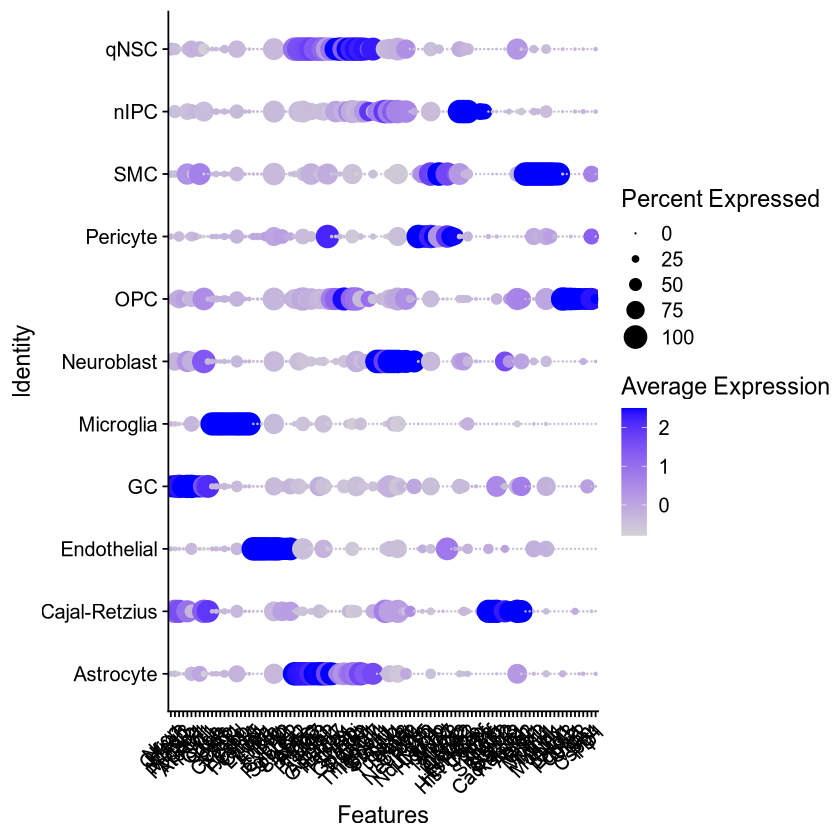

In [25]:
## ===================== 6. 画 DotPlot 看每个细胞类型的 Top10 marker =====================
library(dplyr)

# 确保结果里有 cluster/gene/avg_log2FC 这些列
stopifnot(all(c("cluster", "gene", "avg_log2FC") %in% colnames(markers_celltype)))

top10 <- markers_celltype %>%
  group_by(cluster) %>%
  slice_max(order_by = avg_log2FC, n = 10)

DotPlot(
  combined,
  features = unique(top10$gene),
  group.by = "Celltype_Article"
) + RotatedAxis()


In [ ]:
## ===================== 7. 保存带注释的 combined =====================
saveRDS(
  combined,
  file = file.path(data_dir, "Seurat_combined_with_Celltype_Article.rds")
)